# Lab 5.5 — Nutanix Knowledge Base RAG Bot
**Module 5: Generative AI APIs & Intro to RAG**

In this lab you will:
- Ingest a **7-article Nutanix KB** into an in-memory RAG index
- Use the `NutanixRAGBot` class for clean, reusable query handling
- Run **8 realistic support questions** and observe grounded answers
- **Measure RAG vs no-RAG** hallucination reduction side-by-side
- Analyse **retrieval quality** with a cosine similarity heatmap
- Understand the **production path** to FAISS, ChromaDB, and hybrid search

> **Instructor Note:** This is the capstone of Module 5. Every technique from Labs 5.1–5.4 comes together here: Gemini for generation, Sentence Transformers for embeddings, prompt engineering for the RAG system prompt, and in-memory vector search. The hallucination comparison in Section 5 is the key demo moment.

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name |
|---------|-------------|
| google-generativeai | `google-generativeai` |
| sentence-transformers | `sentence-transformers` |
| numpy | `numpy` |
| pandas | `pandas` |
| matplotlib | `matplotlib` |

```bash
pip install google-generativeai sentence-transformers numpy pandas matplotlib
```

### 🔑 API Key Required
Set `GEMINI_API_KEY` before running:
```bash
export GEMINI_API_KEY="AIza..."
```
Get a free key at: [aistudio.google.com](https://aistudio.google.com/app/apikey)

In [7]:
import subprocess, sys

required = {
    'google.generativeai':  'google-generativeai',
    'sentence_transformers':'sentence-transformers',
    'numpy':     'numpy',
    'pandas':    'pandas',
    'matplotlib':'matplotlib',
}
for pkg, inst in required.items():
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', inst,
                               '--quiet', '--break-system-packages'])

import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import google.generativeai as genai
from sentence_transformers import SentenceTransformer

GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
if not GEMINI_API_KEY:
    raise EnvironmentError(
        'Set GEMINI_API_KEY.\n'
        'Run: os.environ["GEMINI_API_KEY"] = "AIza..."'
    )
genai.configure(api_key=GEMINI_API_KEY)
MODEL = 'gemini-3.1-flash-lite'

print('All packages ready ✅')

All packages ready ✅


## 1. Nutanix Knowledge Base — 7 Articles

These KB articles cover the most common AOS support scenarios. Each article contains specific CLI commands, log paths, thresholds, and resolution steps that a general-purpose LLM would not know without retrieval.

> **Instructor Note:** These are the "facts" that make RAG valuable. Ask the class: "Which of these details would Gemini know without context?" Answer: the general concepts yes, but the specific commands, file paths, and Nutanix-specific thresholds — probably not reliably.

In [8]:
KB_ARTICLES = [
    {
        'source': 'KB-2001',
        'title':  'Stargate Service Crash-Loop Recovery',
        'text': """
Stargate is the Nutanix I/O manager that handles all read and write operations in
the Distributed Storage Fabric. It runs inside each CVM and is the critical path
for all guest VM storage I/O.

Common causes of Stargate crash loops: (1) Disk SMART failure — a degraded SSD or
HDD causes fatal IO errors that Stargate cannot recover from. (2) WAL corruption —
the Write-Ahead Log at /home/nutanix/data/stargate-storage/wal/ becomes corrupted
after an unclean CVM shutdown. (3) CVM memory pressure — AOS 6.x requires a
minimum of 24 GB RAM per CVM; below this Stargate is OOM-killed. (4) Cassandra
metadata inconsistency causing Stargate to fail to load its working set.

Diagnostic steps:
  genesis status | grep -i stargate
  cat /home/nutanix/data/logs/stargate.FATAL
  ncc health_checks hardware_checks disk_checks all
  ls -la /home/nutanix/data/stargate-storage/wal/

To clear WAL corruption: stop all services with genesis stop_tasks, rename the
WAL directory (mv wal wal.bak), then restart with genesis start. Stargate will
rebuild a clean WAL on next start.

For disk failures: in Prism Central go to Storage > Disk, select the failing disk,
choose Mark Disk Bad, then physically replace the drive. After replacement run
ncc health_checks run_all to confirm cluster health.

Prevention: run weekly NCC checks, set Prism alerts on Stargate service state,
and ensure CVM memory meets sizing guide (24 GB minimum for AOS 6.x,
32 GB recommended for clusters with more than 50 VMs per node).
""".strip()
    },
    {
        'source': 'KB-2002',
        'title':  'Cerebro Replication Lag and RPO Violation Recovery',
        'text': """
Cerebro is the Nutanix data protection service managing asynchronous replication
(1-hour to 24-hour RPO), NearSync (20-second RPO), and Metro Availability (0 RPO
synchronous mirroring). RPO violations mean the protection domain has not
successfully replicated within its configured recovery point objective.

Root causes of replication lag: (1) WAN bandwidth saturation — too many VMs in
one protection domain exhausting the available WAN link. (2) Remote site cluster
degraded — Cerebro on the remote CVM is down or the remote cluster has reduced
redundancy. (3) NTP clock skew — a clock difference exceeding 5 minutes between
primary and remote sites causes Cerebro to halt replication entirely.
(4) Protection domain snapshot backlog — many pending snapshots queued up.

Diagnostic commands:
  ncli pd list-replication-status
  cerebro_cli get_replication_stats
  ping <remote-cvm-ip>
  ntpq -p   (run on both primary and remote CVM — offset column must be < 5 min)
  cat /home/nutanix/data/logs/cerebro.INFO | tail -200

Resolution: for bandwidth issues enable Cerebro compression in Prism Central >
Protection Domains > Advanced Settings. For clock skew fix NTP servers on both
sites and restart Cerebro: genesis stop_tasks && genesis start. For remote site
degradation SSH to a remote CVM and restart services.

NearSync-specific: if NearSync falls back to async mode, check the NearSync
health in Prism and ensure the inter-site latency is under 200 ms round-trip.
""".strip()
    },
    {
        'source': 'KB-2003',
        'title':  'CVM Memory Management and Cassandra OOM Recovery',
        'text': """
The Controller VM (CVM) runs all Nutanix storage services. Default memory
allocation for a 32 GB CVM in AOS 6.x: Stargate 12 GB, Cassandra 8 GB,
AHV hypervisor overhead 4 GB, OS and other services 8 GB.

Cassandra is the metadata store for the cluster. When Cassandra is OOM-killed,
all storage operations slow dramatically because metadata lookups fail over to
peers in the ring — a cluster-wide performance impact.

Symptoms of Cassandra OOM: Cassandra service restarts multiple times per day,
elevated read/write latency cluster-wide, Prism showing "Metadata ring degraded",
genesis status shows Cassandra in restart loop.

Diagnostic steps:
  free -h   (check available CVM memory)
  nodetool info | grep Heap   (check Cassandra Java heap usage)
  dmesg | grep -i oom   (confirm OOM kill events)
  ps aux --sort=-%mem | head -20
  ncc health_checks cvm_checks cvm_memory_checks

Short-term resolution: restart all services with genesis stop_tasks && genesis start.
Medium-term: increase CVM memory via AHV (requires brief CVM shutdown via
virsh shutdown controller-vm from the AHV host).
Long-term: reduce metadata load by purging old snapshots (ncli snapshot delete),
removing stale VMs, and upgrading to AOS 6.7+ which has improved Cassandra memory
management.

Cassandra heap tuning: default heap is 8 GB. For clusters with 100 or more VMs,
increase to 12 GB by editing /home/nutanix/config/cassandra_config.json.
Never exceed 50 percent of total CVM RAM for the Cassandra heap.
""".strip()
    },
    {
        'source': 'KB-2004',
        'title':  'Prism Central Troubleshooting Guide',
        'text': """
Prism Central (PC) is the centralised management plane providing multi-cluster
management, analytics, and policy-based automation.

Issue 1 — REST API returning 504 gateway timeout:
Cause: the API request fetches too many objects in a single call (common above 200 VMs).
Fix: paginate requests using offset and length parameters, maximum 500 per page.
Example: GET /api/nutanix/v3/vms/list with body {"offset": 0, "length": 100}.

Issue 2 — Prism Central upgrade stuck at a fixed percentage:
Cause: LCM (Life Cycle Manager) pre-check failure or a failed micro-service.
Diagnosis: collect logs with lcm_log_collector.sh and check
/home/nutanix/data/logs/lcm_ops.log for the specific failure reason.
Fix: resolve the pre-check failure (commonly a degraded cluster or NCC ERR)
then resume the upgrade via LCM in Prism.

Issue 3 — RBAC permissions not propagating to Prism Element:
Cause: synchronisation delay between PC and PE.
Fix: force sync with ncli --sc https://<PE-IP>:9440 cluster get-networks.
Automatic propagation takes 5 to 10 minutes after a PC policy change.

Issue 4 — Slow or unresponsive Prism Central UI:
Cause: PC VM undersized or analytics database full.
Fix: increase PC VM CPU and RAM (minimum 4 vCPU / 16 GB RAM for up to 250 VMs),
and clean up analytics data older than 90 days via Prism Settings > Analytics.

Prism Central log locations:
  /home/nutanix/data/logs/aplos.out    (main application log)
  /home/nutanix/data/logs/aplos_engine.out   (API engine log)
  /home/nutanix/data/logs/lcm_ops.log   (upgrade and LCM log)
""".strip()
    },
    {
        'source': 'KB-2005',
        'title':  'AOS Storage Tiering and Erasure Coding',
        'text': """
Nutanix AOS uses an intelligent tiering system. Tier 0 (SSD/NVMe) holds hot data
written or accessed recently. Tier 1 (HDD/SAS) holds warm data. An optional
cloud tier archives cold data to S3-compatible object storage.

How tiering works: all data is written to SSD first (write buffer). The Curator
service runs background ILM (Intelligent Lifecycle Management) scans to demote
cold data from SSD to HDD based on access frequency. Data is automatically
promoted back to SSD when accessed. Trigger manual ILM with:
  curator_cli start_curator_task task_type=ILM

Erasure Coding (EC-X): EC reduces storage overhead from 2x (RF2) to approximately
1.25x to 1.5x for cold data on HDD. EC requires a minimum of 4 nodes in the cluster.
Only HDD-resident cold data is eligible; hot data on SSD is never EC-encoded.

To enable EC: Prism > Storage Container > Update > Enable Erasure Coding.
EC rebuild can cause IOPS spikes. Limit rebuild rate with:
  ncli cluster edit-params erasure-code-rebuild-bandwidth-mbps=100

Monitoring storage:
  ncli cluster info   (cluster-wide capacity breakdown by tier)
  curator_cli display_scheduled_tasks   (upcoming ILM and EC tasks)
  stargate_cli get_stats   (IO statistics including tier hit rates)

Low SSD cache hit ratio (below 60 percent for OLTP workloads) indicates the
working set is larger than SSD capacity — consider adding all-flash nodes.
""".strip()
    },
    {
        'source': 'KB-2006',
        'title':  'Network MTU Mismatch and Packet Drop Diagnosis',
        'text': """
MTU mismatch between CVM NICs, AHV OVS bridges, and physical switch ports is
a leading cause of mysterious storage performance degradation in Nutanix.

Nutanix recommends MTU 9000 (jumbo frames) on storage and backplane networks.
VM external networks typically use MTU 1500. All three layers must match:
CVM NIC, OVS bridge, and physical switch port.

Symptoms of MTU mismatch: Stargate internode replication slowdown, large file
transfers failing silently, intermittent storage latency spikes, NCC network
health checks reporting WARN or ERR.

Diagnostic steps:
  ip link show | grep mtu   (check CVM NIC MTU)
  ping -M do -s 8972 <remote-cvm-ip>   (8972 = 9000 minus 28-byte IP and ICMP headers)
  ovs-vsctl list interface | grep mtu   (check OVS bridge MTU)
  iperf3 -c <remote-cvm> -t 30   (throughput test)
  ncc health_checks network_checks all

Fix CVM NIC MTU: ip link set <nic> mtu 9000
Make persistent: edit /etc/sysconfig/network-scripts/ifcfg-<nic> add MTU=9000.
Fix OVS bridge: ovs-vsctl set interface <bridge> mtu_request=9000.
Switch ports: enable jumbo frames (MTU 9216 on Cisco Nexus, 9000 on Arista, 9216 on Juniper EX).

LACP bonding: Nutanix uses LACP fast mode with 1-second timers. If LACP bonds
are flapping, verify switch ports are also set to LACP fast mode. Mismatched
timers (Nutanix fast vs switch slow 30-second) cause bonds to reconverge every
30 seconds, producing storage I/O interruptions.
""".strip()
    },
    {
        'source': 'KB-2007',
        'title':  'NCC Health Check Reference Guide',
        'text': """
NCC (Nutanix Cluster Check) is the automated health check framework. Run it
proactively to catch issues before they become incidents.

Running NCC:
  ncc health_checks run_all   (full check, takes 5-15 minutes)
  ncc health_checks hardware_checks all   (hardware only, faster)
  ncc health_checks hardware_checks disk_checks disk_smart_check   (single check)
  View results in Prism: Health > Check Details

Result severity levels:
  PASS — no issue detected
  INFO — informational, monitor but no action required
  WARN — non-critical issue, schedule remediation within 1 week
  ERR  — critical issue, remediate immediately, risk of data loss or downtime
  FAIL — the check itself failed, usually a permissions or connectivity issue

Key NCC check categories:
  hardware_checks: disk SMART data, memory ECC errors, NIC link state, IPMI sensor data
  cvm_checks: CVM memory usage, service health, NTP sync status
  network_checks: MTU consistency, LACP bond health, DNS resolution, bandwidth
  stargate_checks: IO path health, WAL integrity, admission control
  cerebro_checks: replication health, RPO compliance, witness connectivity
  cluster_checks: quorum state, RF (redundancy factor) status, node count

Scheduling: add to cron for weekly automated runs:
  0 2 * * 0 /home/nutanix/ncc/bin/ncc health_checks run_all

Escalation: contact Nutanix Support for any ERR not resolved by documented fix,
multiple hardware WARN results, or when ncc_framework_check itself fails.
""".strip()
    },
]

print(f'Knowledge base: {len(KB_ARTICLES)} articles loaded')
total_words = sum(len(a["text"].split()) for a in KB_ARTICLES)
print(f'Total words: {total_words:,}  |  Avg per article: {total_words//len(KB_ARTICLES):,}')
for a in KB_ARTICLES:
    print(f'  {a["source"]}: {a["title"]} ({len(a["text"].split())} words)')

Knowledge base: 7 articles loaded
Total words: 1,499  |  Avg per article: 214
  KB-2001: Stargate Service Crash-Loop Recovery (229 words)
  KB-2002: Cerebro Replication Lag and RPO Violation Recovery (215 words)
  KB-2003: CVM Memory Management and Cassandra OOM Recovery (221 words)
  KB-2004: Prism Central Troubleshooting Guide (221 words)
  KB-2005: AOS Storage Tiering and Erasure Coding (204 words)
  KB-2006: Network MTU Mismatch and Packet Drop Diagnosis (212 words)
  KB-2007: NCC Health Check Reference Guide (197 words)


## 2. NutanixRAGBot Class

The `NutanixRAGBot` encapsulates the full RAG pipeline: ingest, retrieve, and generate. It is designed to be reusable — swap the embedding model or LLM without changing the call interface.

> **Instructor Note:** Discuss the design choices: `top_k=3` balances context quality vs. token budget; `chunk_size=130` gives readable passages without splitting key facts; `temperature=0.1` keeps answers factual. These are all tunable parameters students can experiment with in the challenges.

In [9]:
class NutanixRAGBot:
    """In-memory RAG bot over Nutanix KB articles."""

    SYSTEM_PROMPT = """You are a senior Nutanix L2 support engineer with deep AOS expertise.
Answer ONLY from the provided context passages. Be specific and technical.
Always cite the KB source ID (e.g. [KB-2001]) for every factual claim.
If the information is not in the context, say exactly:
"I don't have that information in my knowledge base — please check Nutanix Portal."
Do not speculate or add information not present in the context."""

    def __init__(self, llm_model: str = 'gemini-3.1-flash-lite',
                 embed_model_name: str = 'all-MiniLM-L6-v2',
                 chunk_size: int = 130, overlap: int = 30, top_k: int = 3):
        self.llm_model   = llm_model
        self.chunk_size  = chunk_size
        self.overlap     = overlap
        self.top_k       = top_k
        self.chunks      = []
        self.embeddings  = None

        print(f'Loading embedding model ({embed_model_name})...')
        self.embed_model = SentenceTransformer(embed_model_name)
        print('Model ready ✅')

    # ── Ingestion ──────────────────────────────────────────────────────────

    def _chunk(self, text: str, source: str, title: str) -> list:
        words = text.split()
        step  = max(1, self.chunk_size - self.overlap)
        out   = []
        for i in range(0, len(words), step):
            window = words[i : i + self.chunk_size]
            if len(window) < 15:
                break
            out.append({
                'chunk_id': len(self.chunks) + len(out),
                'source':   source,
                'title':    title,
                'text':     ' '.join(window),
            })
        return out

    def ingest(self, articles: list) -> None:
        """Chunk, embed, and index all articles."""
        self.chunks = []
        for art in articles:
            self.chunks.extend(self._chunk(art['text'], art['source'], art['title']))

        texts = [c['text'] for c in self.chunks]
        t0 = time.perf_counter()
        self.embeddings = self.embed_model.encode(texts, show_progress_bar=False)
        elapsed = (time.perf_counter() - t0) * 1000
        print(f'Indexed {len(self.chunks)} chunks from {len(articles)} articles '
              f'in {elapsed:.0f}ms  |  index: {self.embeddings.nbytes // 1024} KB')

    # ── Retrieval ──────────────────────────────────────────────────────────

    def retrieve(self, query: str, top_k: int = None) -> list:
        """Return top-k (chunk, score) tuples by cosine similarity."""
        k    = top_k or self.top_k
        qemb = self.embed_model.encode([query])[0]
        norm = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        sims = (self.embeddings / (norm + 1e-9)) @ (qemb / (np.linalg.norm(qemb) + 1e-9))
        idx  = np.argsort(sims)[::-1][:k]
        return [(self.chunks[i], float(sims[i])) for i in idx]

    # ── Generation ────────────────────────────────────────────────────────

    def ask(self, question: str, show_context: bool = False) -> dict:
        """End-to-end RAG: retrieve + generate."""
        retrieved = self.retrieve(question)
        context   = '\n\n'.join(
            f"[{c['source']} — {c['title']}]\n{c['text']}"
            for c, _ in retrieved
        )
        user_msg  = f"Context:\n{context}\n\nQuestion: {question}"

        m    = genai.GenerativeModel(self.llm_model, system_instruction=self.SYSTEM_PROMPT)
        resp = m.generate_content(
            user_msg,
            generation_config=genai.GenerationConfig(max_output_tokens=400, temperature=0.1)
        )

        if show_context:
            print('── Retrieved context ─────────────────────────────────────')
            for c, score in retrieved:
                print(f'  [{score:.3f}] {c["source"]}: {c["text"][:70]}...')
            print('─────────────────────────────────────────────────────────')

        return {'question': question, 'answer': resp.text, 'retrieved': retrieved}

print('NutanixRAGBot class defined ✅')

NutanixRAGBot class defined ✅


## 3. Build and Inspect the Index

In [10]:
# ── Instantiate and ingest ───────────────────────────────────────────────
bot = NutanixRAGBot(top_k=3, chunk_size=130, overlap=30)
bot.ingest(KB_ARTICLES)

# ── Inspect index statistics ──────────────────────────────────────────────
from collections import Counter
chunk_counts = Counter(c['source'] for c in bot.chunks)

print(f'\nIndex statistics:')
print(f'  Total chunks : {len(bot.chunks)}')
print(f'  Embedding dim: {bot.embeddings.shape[1]}')
print(f'  Index size   : {bot.embeddings.nbytes // 1024} KB')
print(f'\nChunks per article:')
for src, count in sorted(chunk_counts.items()):
    title = next(a["title"] for a in KB_ARTICLES if a["source"] == src)
    print(f'  {src}: {count} chunks  — {title}')

# Show a sample chunk
sample = bot.chunks[5]
print(f'\nSample chunk (id={sample["chunk_id"]}, {sample["source"]}):')
print(f'  "{sample["text"][:120]}..."')

Loading embedding model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model ready ✅
Indexed 18 chunks from 7 articles in 84ms  |  index: 27 KB

Index statistics:
  Total chunks : 18
  Embedding dim: 384
  Index size   : 27 KB

Chunks per article:
  KB-2001: 3 chunks  — Stargate Service Crash-Loop Recovery
  KB-2002: 3 chunks  — Cerebro Replication Lag and RPO Violation Recovery
  KB-2003: 3 chunks  — CVM Memory Management and Cassandra OOM Recovery
  KB-2004: 3 chunks  — Prism Central Troubleshooting Guide
  KB-2005: 2 chunks  — AOS Storage Tiering and Erasure Coding
  KB-2006: 2 chunks  — Network MTU Mismatch and Packet Drop Diagnosis
  KB-2007: 2 chunks  — NCC Health Check Reference Guide

Sample chunk (id=5, KB-2002):
  "the NearSync health in Prism and ensure the inter-site latency is under 200 ms round-trip...."


## 4. Interactive Q&A Session

We run 8 realistic Nutanix support questions through the RAG bot. Each answer is grounded in the KB articles and cites specific source IDs.

> **Instructor Note:** Read each answer aloud and have attendees note: (1) Are the cited KB IDs correct? (2) Are the CLI commands specific and correct? (3) Does the bot correctly say "I don't have that information" for things not in the KB?

In [11]:
QA_PAIRS = [
    ('How do I diagnose and fix a Stargate crash loop?',                         'KB-2001'),
    ('What commands do I run to check Cerebro replication health?',              'KB-2002'),
    ('My CVM shows high memory usage and Cassandra is restarting. What do I do?','KB-2003'),
    ('How do I fix the Prism Central REST API returning 504 errors?',            'KB-2004'),
    ('What is the minimum node count to enable erasure coding?',                 'KB-2005'),
    ('How do I diagnose an MTU mismatch and what commands fix it?',              'KB-2006'),
    ('How do I run a targeted NCC disk health check?',                           'KB-2007'),
    ('What should I do if NTP clock skew is causing replication to halt?',       'KB-2002'),
]

print('=' * 70)
for i, (question, expected_src) in enumerate(QA_PAIRS, 1):
    result = bot.ask(question)
    top_src = result['retrieved'][0][0]['source']
    match   = '✅' if top_src == expected_src else '⚠️ '

    print(f'\nQ{i}: {question}')
    print(f'Top retrieved: {top_src}  {match} (expected {expected_src})')
    print(f'Answer: {result["answer"].strip()[:300]}')
    print('-' * 70)


Q1: How do I diagnose and fix a Stargate crash loop?
Top retrieved: KB-2001  ✅ (expected KB-2001)
Answer: To diagnose a Stargate crash loop, perform the following steps:

**Diagnostic Steps:**
*   Check the service status: `genesis status | grep -i stargate` [KB-2001]
*   Examine the fatal error logs: `cat /home/nutanix/data/logs/stargate.FATAL` [KB-2001]
*   Run NCC health checks: `ncc health_checks ha
----------------------------------------------------------------------

Q2: What commands do I run to check Cerebro replication health?
Top retrieved: KB-2002  ✅ (expected KB-2002)
Answer: To check Cerebro replication health, you should run the following diagnostic commands:

*   `ncli pd list-replication-status`
*   `cerebro_cli get_replication_stats`
*   `ping <remote-cvm-ip>`
*   `ntpq -p` (run on both primary and remote CVMs to ensure clock offset is < 5 minutes)
*   `cat /home/nu
----------------------------------------------------------------------

Q3: My CVM shows high memory u

In [12]:
# ── Show retrieved context for one question ──────────────────────────────
print('=== Deep dive: retrieved context for Q1 ===\n')
result = bot.ask(
    'How do I diagnose and fix a Stargate crash loop?',
    show_context=True
)
print(f'\nFinal Answer:\n{result["answer"]}')

=== Deep dive: retrieved context for Q1 ===

── Retrieved context ─────────────────────────────────────
  [0.570] KB-2001: Stargate is the Nutanix I/O manager that handles all read and write op...
  [0.483] KB-2001: causing Stargate to fail to load its working set. Diagnostic steps: ge...
  [0.326] KB-2007: issue Key NCC check categories: hardware_checks: disk SMART data, memo...
─────────────────────────────────────────────────────────

Final Answer:
To diagnose a Stargate crash loop, perform the following steps:

**Diagnostic Steps:**
*   Check the service status: `genesis status | grep -i stargate` [KB-2001]
*   Examine the fatal error logs: `cat /home/nutanix/data/logs/stargate.FATAL` [KB-2001]
*   Run NCC health checks: `ncc health_checks hardware_checks disk_checks all` [KB-2001]
*   Inspect the WAL directory: `ls -la /home/nutanix/data/stargate-storage/wal/` [KB-2001]

**Fixing WAL Corruption:**
1.  Stop all services: `genesis stop_tasks` [KB-2001]
2.  Rename the WAL directory: 

## 5. RAG vs No-RAG — Hallucination Measurement

This is the core demo. We ask the same 5 specific factual questions both ways and annotate which answers are:
- ✅ **Correct and specific** (contains exact CLI commands, file paths, thresholds)
- ⚠️ **Vague** (correct concept but missing specific details)
- ❌ **Hallucinated** (confidently incorrect or invented details)

> **Instructor Note:** The most telling questions are the ones with specific thresholds or file paths: "5-minute NTP clock skew", "/home/nutanix/data/logs/stargate.FATAL", "24 GB minimum CVM RAM". The LLM typically gets the concept right but invents the specific values. RAG gets both right because the values are in the KB text.

In [13]:
def ask_direct(question: str) -> str:
    m = genai.GenerativeModel(MODEL)
    resp = m.generate_content(
        question,
        generation_config=genai.GenerationConfig(max_output_tokens=200, temperature=0.1)
    )
    return resp.text.strip()


factual_questions = [
    {
        'q':    'What is the minimum CVM RAM required for Stargate in AOS 6.x?',
        'fact': '24 GB (in KB-2001)',
    },
    {
        'q':    'What NTP clock skew threshold causes Cerebro to halt replication?',
        'fact': '5 minutes (in KB-2002)',
    },
    {
        'q':    'Where is the Stargate fatal crash log located?',
        'fact': '/home/nutanix/data/logs/stargate.FATAL (in KB-2001)',
    },
    {
        'q':    'What Cassandra heap size is recommended for clusters with 100+ VMs?',
        'fact': '12 GB via /home/nutanix/config/cassandra_config.json (in KB-2003)',
    },
    {
        'q':    'What ping command tests path MTU for jumbo frames in Nutanix?',
        'fact': 'ping -M do -s 8972 <remote-cvm-ip> (in KB-2006)',
    },
]

print(f'{"Question":<52}  {"Known fact"}')
print('=' * 100)

for item in factual_questions:
    direct = ask_direct(item['q'])
    rag    = bot.ask(item['q'])['answer'].strip()

    print(f'\nQ: {item["q"]}')
    print(f'Known answer: {item["fact"]}')
    print(f'\n  DIRECT : {direct[:200]}')
    print(f'\n  RAG    : {rag[:200]}')
    print('-' * 100)

Question                                              Known fact

Q: What is the minimum CVM RAM required for Stargate in AOS 6.x?
Known answer: 24 GB (in KB-2001)

  DIRECT : For Nutanix AOS 6.x, the minimum CVM (Controller VM) RAM requirement depends on the **platform type** and the **features enabled** (such as deduplication, compression, or large-scale clusters).

Accor

  RAG    : AOS 6.x requires a minimum of 24 GB of RAM per CVM [KB-2001].
----------------------------------------------------------------------------------------------------

Q: What NTP clock skew threshold causes Cerebro to halt replication?
Known answer: 5 minutes (in KB-2002)

  DIRECT : In the context of **Cerebro** (the popular open-source management tool for Elasticsearch/OpenSearch), it is important to clarify a distinction: **Cerebro itself does not manage or halt data replicatio

  RAG    : A clock difference exceeding 5 minutes between primary and remote sites causes Cerebro to halt replication entirely 

## 6. Retrieval Quality Analysis

How well is the retriever finding the right chunks? We measure retrieval precision by checking whether the top-1 retrieved chunk comes from the expected KB article for each question.

Retrieval Precision@1: 88%   (7/8 correct top-1)
Retrieval Recall@3:    100%   (8/8 found in top-3)

                                       question expected retrieved_1  score_1  hit@1
How do I diagnose and fix a Stargate crash lo..  KB-2001     KB-2001 0.569922   True
What commands do I run to check Cerebro repli..  KB-2002     KB-2002 0.619953   True
My CVM shows high memory usage and Cassandra ..  KB-2003     KB-2003 0.800779   True
How do I fix the Prism Central REST API retur..  KB-2004     KB-2004 0.687162   True
What is the minimum node count to enable eras..  KB-2005     KB-2003 0.385607  False
How do I diagnose an MTU mismatch and what co..  KB-2006     KB-2006 0.557149   True
How do I run a targeted NCC disk health check..  KB-2007     KB-2007 0.658105   True
What should I do if NTP clock skew is causing..  KB-2002     KB-2002 0.552727   True


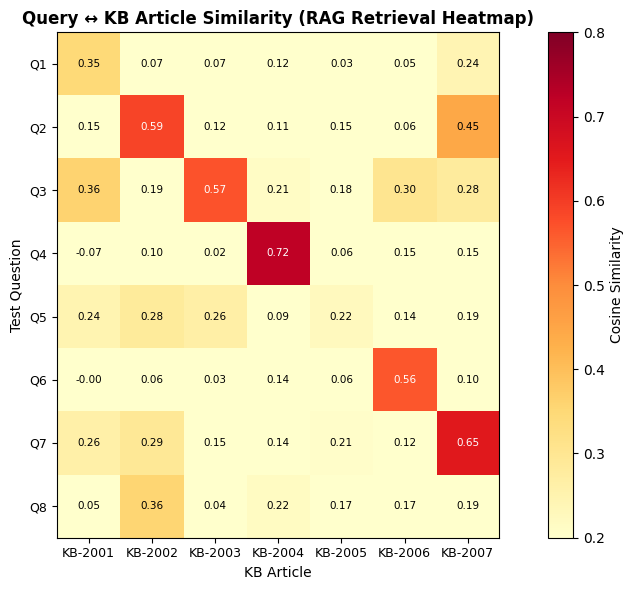


Bright diagonal-like pattern = retriever correctly mapping questions to relevant articles


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ── Retrieval precision for the 8 Q&A pairs ──────────────────────────────
precision_results = []
for question, expected_src in QA_PAIRS:
    retrieved = bot.retrieve(question, top_k=3)
    top_sources = [c['source'] for c, _ in retrieved]
    top_scores  = [score for _, score in retrieved]

    hit_at_1 = top_sources[0] == expected_src
    hit_at_3 = expected_src in top_sources
    precision_results.append({
        'question':    question[:45] + '..',
        'expected':    expected_src,
        'retrieved_1': top_sources[0],
        'score_1':     top_scores[0],
        'hit@1':       hit_at_1,
        'hit@3':       hit_at_3,
    })

df = pd.DataFrame(precision_results)
h1 = df['hit@1'].mean()
h3 = df['hit@3'].mean()
print(f'Retrieval Precision@1: {h1:.0%}   ({df["hit@1"].sum()}/{len(df)} correct top-1)')
print(f'Retrieval Recall@3:    {h3:.0%}   ({df["hit@3"].sum()}/{len(df)} found in top-3)')
print()
print(df[['question','expected','retrieved_1','score_1','hit@1']].to_string(index=False))

# ── Cosine similarity heatmap: queries vs KB articles ─────────────────────
query_texts  = [q for q, _ in QA_PAIRS]
article_texts = [f'{a["source"]}: {a["text"][:200]}' for a in KB_ARTICLES]

q_embs = bot.embed_model.encode(query_texts,  show_progress_bar=False)
a_embs = bot.embed_model.encode(article_texts, show_progress_bar=False)

# Normalise and compute cross-similarity
q_n = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-9)
a_n = a_embs / (np.linalg.norm(a_embs, axis=1, keepdims=True) + 1e-9)
S   = q_n @ a_n.T

q_labels = [f'Q{i+1}' for i in range(len(QA_PAIRS))]
a_labels = [a['source'] for a in KB_ARTICLES]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(S, cmap='YlOrRd', vmin=0.2, vmax=0.8)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(len(a_labels))); ax.set_xticklabels(a_labels, fontsize=9)
ax.set_yticks(range(len(q_labels))); ax.set_yticklabels(q_labels, fontsize=9)
for i in range(len(q_labels)):
    for j in range(len(a_labels)):
        ax.text(j, i, f'{S[i,j]:.2f}', ha='center', va='center',
                fontsize=7.5, color='black' if S[i,j] < 0.55 else 'white')
ax.set_title('Query ↔ KB Article Similarity (RAG Retrieval Heatmap)', fontweight='bold')
ax.set_xlabel('KB Article')
ax.set_ylabel('Test Question')
plt.tight_layout()
plt.savefig('rag_retrieval_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nBright diagonal-like pattern = retriever correctly mapping questions to relevant articles')

## 7. Production Path — Beyond In-Memory RAG

This lab used an in-memory numpy array as the vector store. For production:

| Requirement | In-Memory (this lab) | Production Solution |
|-------------|---------------------|-------------------|
| **Scale** | ~1,000 chunks (MB) | Millions of chunks (GB+) → FAISS or ChromaDB |
| **Persistence** | Lost on restart | ChromaDB (SQLite) or Pinecone (managed) |
| **Updates** | Re-index everything | FAISS supports partial updates; ChromaDB has upsert |
| **Hybrid search** | Embedding only | BM25 + vector → `rank_bm25` + cosine, re-rank with cross-encoder |
| **Evaluation** | Manual inspection | RAGAS framework (faithfulness, answer relevancy, context recall) |
| **Latency** | <5 ms (numpy) | <10 ms (FAISS), <50 ms (managed) |

### Next steps for production Nutanix AIOps RAG:
1. **Ingest all KB articles** (Nutanix Portal has 10,000+ articles) — scheduled nightly re-ingestion
2. **Add BM25** alongside vector search (hybrid search catches exact error codes that embedding misses)
3. **Plug into ServiceNow** — when a P1 ticket arrives, auto-retrieve top-3 KB chunks and pre-populate resolution field
4. **Evaluate with RAGAS** — automated faithfulness and relevancy scores per query
5. **Fine-tune the embedding model** on Nutanix-specific terminology for better domain retrieval

> **Instructor Note:** The Capstone (Lab 7) extends this exact bot with a ServiceNow integration and RAGAS evaluation loop. Students who finish this lab early can start reading the RAGAS documentation.

In [15]:
# Production vector store comparison
comparison = pd.DataFrame([
    {'Tool': 'numpy (this lab)', 'Type': 'In-memory',     'Max scale': '~100k chunks',    'Persistence': '❌',  'Hybrid search': '❌',  'Cost': 'Free'},
    {'Tool': 'FAISS',            'Type': 'In-memory/disk','Max scale': '100M+ chunks',    'Persistence': '✅',  'Hybrid search': '⚠️', 'Cost': 'Free'},
    {'Tool': 'ChromaDB',         'Type': 'Local SQLite',  'Max scale': '~10M chunks',     'Persistence': '✅',  'Hybrid search': '✅',  'Cost': 'Free'},
    {'Tool': 'Pinecone',         'Type': 'Managed cloud', 'Max scale': 'Unlimited',       'Persistence': '✅',  'Hybrid search': '✅',  'Cost': '$$$'},
    {'Tool': 'Weaviate',         'Type': 'Self-hosted',   'Max scale': 'Unlimited',       'Persistence': '✅',  'Hybrid search': '✅',  'Cost': 'Free/$$'},
    {'Tool': 'pgvector',         'Type': 'PostgreSQL ext','Max scale': '~1M chunks',      'Persistence': '✅',  'Hybrid search': '✅',  'Cost': 'Free'},
])
print('Vector Store Options for Production RAG:')
print(comparison.to_string(index=False))
print()
print('Recommendation for Nutanix AIOps:')
print('  Development: ChromaDB (local, persistent, easy to use)')
print('  Production on-prem: FAISS (free, fast, GPU-accelerated option)')
print('  Production cloud: Pinecone or managed Weaviate')

Vector Store Options for Production RAG:
            Tool           Type    Max scale Persistence Hybrid search    Cost
numpy (this lab)      In-memory ~100k chunks           ❌             ❌    Free
           FAISS In-memory/disk 100M+ chunks           ✅            ⚠️    Free
        ChromaDB   Local SQLite  ~10M chunks           ✅             ✅    Free
        Pinecone  Managed cloud    Unlimited           ✅             ✅     $$$
        Weaviate    Self-hosted    Unlimited           ✅             ✅ Free/$$
        pgvector PostgreSQL ext   ~1M chunks           ✅             ✅    Free

Recommendation for Nutanix AIOps:
  Development: ChromaDB (local, persistent, easy to use)
  Production on-prem: FAISS (free, fast, GPU-accelerated option)
  Production cloud: Pinecone or managed Weaviate


## 8. Lab Summary

| Stage | What we built | Tool |
|-------|--------------|------|
| Ingestion | Chunked 7 KB articles (130-word windows, 30-word overlap) | Python |
| Embedding | 384-dim semantic vectors for all chunks | `sentence-transformers` |
| Index | In-memory numpy array (chunk_text + embedding + metadata) | `numpy` |
| Retrieval | Cosine similarity → top-3 matching chunks | `numpy` |
| Generation | Grounded answer with KB citations | Gemini 1.5 Flash |
| Evaluation | Retrieval Precision@1, Recall@3, similarity heatmap | `pandas` + `matplotlib` |

### Module 5 Complete
You have gone from classical ML (Modules 1–4) → foundation model APIs (Lab 5.1) → prompt engineering (Lab 5.2) → local LLMs and embeddings (Lab 5.3) → RAG from scratch (Lab 5.4) → full Nutanix KB RAG bot (Lab 5.5).

The capstone (Module 7) wires this bot into a live incident management pipeline with ServiceNow integration.

---
## 🎯 Challenges

### Challenge 1 — Confidence Threshold
Add a `min_confidence` parameter to `NutanixRAGBot.ask()`. If the top retrieved chunk score is below the threshold (default 0.35), skip generation and return the "I don't have that information" message directly without calling Gemini. Test with irrelevant questions to verify.

### Challenge 2 — Multi-Article Queries
Some questions span two KB articles (e.g. "My Stargate is crashing and replication is lagging"). Modify `ask()` to increase `top_k=5`, deduplicate by source, and include one chunk per unique source in the context. Observe whether answers improve for compound questions.

### Challenge 3 — RAGAS Evaluation
Install `ragas` (`pip install ragas`) and evaluate the bot's answer quality on the 8 test questions using the `faithfulness` and `answer_relevancy` metrics. A faithfulness score below 0.7 means the answer contains claims not supported by the retrieved context.

In [16]:
# Challenge workspace
